#**LOAN RISK SCORING**
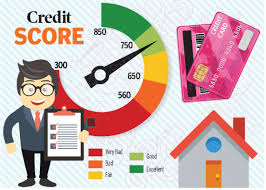

###**BUSINESS PROBLEM**
Lenders need to accurately determine which borrowers are likely to repay loans and which pose a high risk of default. Traditional credit scoring methods rely heavily on static and limited data, often missing real-time behvioural signals such as spending patterns, fraud activity and recent payment behaviour. This leaves a challenge of how financial institutions can continuously and accurately assess borrower risk using dynamic, multi-source data.

This project addresses the gap by building a data pipeline that integrates transaction data, credit history and income information to generate data-driven risk scores. By incorporating behavioural indicators like debt-to-income ratio, late payment trends and fraud signals, the system enables more informed loan decisions, reduces default rates and improves overall credit risk management.

###**OVERVIEW**
This project builds a Loan Risk Scoring Data Pipeline that:


*   Aggregates transaction behaviour, credit history and income data.
*   Engineers meaningful features like Debt-to-income ratio, Fraud Indicators, Late Payment Trends.
* Produces a dynamic risk score for each user.
* Supports downstream syatems such as loan approval engines.



###**SYSTEM ARCHITECTURE DIAGRAM**

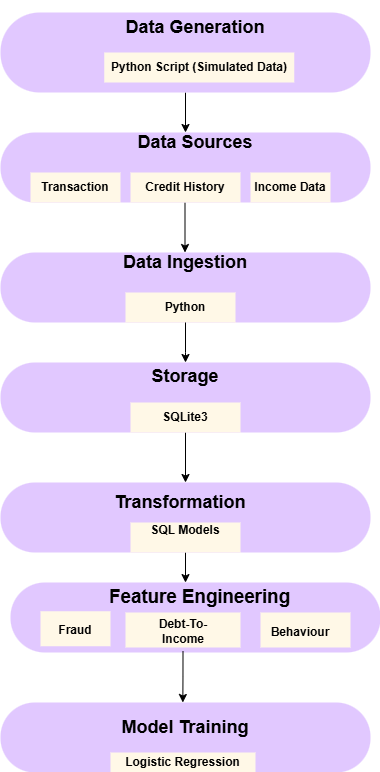

###**DATASET DESCRIPTION**

The dataset used in this project is a mock dataset. The dataset consists of three tables that have beed joined together to make up one dataset. The tables are:
* Transaction Table
* Credit History
* Income

####**Import Libraries**

In [37]:
import pandas as pd
import numpy as np

#####**Transaction Table**

In [38]:
# creating the mock transaction table
np.random.seed(42)

# generate user ids
# generate for three countries (Nigeria, Ghana, Kenya)
Countries = ["NG", "GH", "KE"]
ids = [f"{np.random.choice(Countries)}-USER-{i:03d}"
              for i in np.random.randint(1, 101, size = 1000)]

# generate dates from 1st December 2025 to 20th March 2026
dates = pd.date_range(start = "2025-12-01", end = "2026-03-20")
sample_dates = np.random.choice(dates, size = 1000)
sorted_dates = np.sort(sample_dates)

# generate amount
base_amount = np.random.randint(1, 2000, 1000) * 100

# Add bigger structured payments
large_pay = np.random.choice(
    [50000, 100000, 150000, 200000, 500000, 1000000],
    size = 1000
)
# put the bigger structure & random amounts together
amount = np.where(
    np.random.rand(1000) < 0.85, # 85% normal transactions
    base_amount,
    large_pay
)



transaction = pd.DataFrame({
    "User_id": ids,
    "Amount": amount,
    "Type": np.random.choice(["Debit", "Credit"], 1000),
    "Date": sorted_dates
})
transaction.to_csv("Transactions.csv", index = False)

In [39]:
# verify
Trans = pd.read_csv("/content/Transactions.csv")
Trans.head()

,User_id,Amount,Type,Date
0,GH-USER-052,121000,Debit,2025-12-01
1,KE-USER-093,168000,Credit,2025-12-01
2,NG-USER-015,160800,Debit,2025-12-01
3,KE-USER-072,12900,Credit,2025-12-01
4,GH-USER-061,150000,Credit,2025-12-01


In [40]:
# the unique users
Trans["User_id"].unique()

array(['GH-USER-052', 'KE-USER-093', 'NG-USER-015', 'KE-USER-072',
       'GH-USER-061', 'NG-USER-021', 'NG-USER-083', 'GH-USER-087',
       'GH-USER-075', 'KE-USER-088', 'KE-USER-100', 'NG-USER-024',
       'GH-USER-003', 'NG-USER-022', 'NG-USER-053', 'NG-USER-002',
       'NG-USER-088', 'GH-USER-030', 'NG-USER-038', 'GH-USER-002',
       'GH-USER-064', 'KE-USER-060', 'GH-USER-021', 'KE-USER-033',
       'GH-USER-076', 'GH-USER-058', 'GH-USER-022', 'KE-USER-089',
       'KE-USER-049', 'NG-USER-091', 'KE-USER-059', 'KE-USER-042',
       'KE-USER-092', 'NG-USER-080', 'KE-USER-015', 'GH-USER-062',
       'KE-USER-047', 'KE-USER-062', 'GH-USER-051', 'GH-USER-055',
       'NG-USER-064', 'KE-USER-007', 'NG-USER-073', 'GH-USER-039',
       'KE-USER-018', 'KE-USER-004', 'GH-USER-089', 'NG-USER-014',
       'NG-USER-009', 'GH-USER-090', 'GH-USER-053', 'KE-USER-084',
       'NG-USER-092', 'NG-USER-060', 'KE-USER-071', 'NG-USER-044',
       'GH-USER-008', 'GH-USER-047', 'GH-USER-035', 'NG-USER-0

#####**Credit History**

In [41]:
# creating the mock credit history table

# generate the unique users as same ones created from the transaction table
users = Trans["User_id"].unique()
n_users = len(users)

# generate loan count (the number of past loans)
loan_count = np.random.randint(0, 11, size = n_users)

# generate missed payments (the number of repayment missed)
# putting in mind that more loans most likely would result in higher chance of missed payments
missed_payments = np.array([
    np.random.randint(0, min(loan + 1, 6)) for loan in loan_count
])

# generate credit_utilization
# putting in mind that higher missed payments results in higher utilization
credit_utilization = np.clip(
    np.random.normal(0.3 + (missed_payments * 0.1), 0.2),
    0, 1
)

# generate the credit history table
credit_history = pd.DataFrame({
    "User_id": users,
    "Loan_count": loan_count,
    "Missed_payments": missed_payments,
    "Credit_utilization": np.round(credit_utilization, 2)
})
credit_history.to_csv("Credit_History.csv", index = False)

In [42]:
# verify
Cred_hist= pd.read_csv("/content/Credit_History.csv")
Cred_hist.head()

,User_id,Loan_count,Missed_payments,Credit_utilization
0,GH-USER-052,4,1,0.18
1,KE-USER-093,3,0,0.48
2,NG-USER-015,1,1,0.62
3,KE-USER-072,1,1,0.48
4,GH-USER-061,3,0,0.00


#####**Income Table**

In [43]:
# generate the mock income table

np.random.seed(42)

# generate the unique users as same with the other tables
users = Trans["User_id"].unique()
# number of unique users
n_users = len(users)

# generate jpb type
job_types = np.random.choice(["Employed", "Self-Employed"],
                             size = n_users,
                             p = [0.6, 0.4]) # shows percentage of users by job types
                             # 60% of users should be employed, while 40% should be self-employed

# generate salary
# salary buckets
employed_salaries = [
    50000, 80000, 100000, 120000, 150000,
    180000, 200000, 250000, 300000
]
self_employed_salaries = [
    30000, 50000, 80000, 120000, 200000,
    300000, 500000, 800000
]

# creating based on job_type's weight
employed_weights = [0.05, 0.10, 0.15, 0.20, 0.20, 0.10, 0.08, 0.07, 0.05]
self_employed_weights = [0.10, 0.15, 0.20, 0.20, 0.15, 0.10, 0.07, 0.03]

# generate
salary = np.array([
    np.random.choice(employed_salaries, p = employed_weights)
    if job == "Employed"
    else np.random.choice(self_employed_salaries, p = self_employed_weights)
    for job in job_types
])

# generate the table
income_table = pd.DataFrame({
    "user_id": users,
    "Salary": salary,
    "Job_type": job_types
})

income_table.to_csv("Income.csv", index = False)

In [44]:
# verify
pd.read_csv("/content/Income.csv").head()

,user_id,Salary,Job_type
0,GH-USER-052,100000,Employed
1,KE-USER-093,120000,Self-Employed
2,NG-USER-015,30000,Self-Employed
3,KE-USER-072,50000,Employed
4,GH-USER-061,200000,Employed


#####**Merge all Tables**

In [45]:
# merge credit history & income

user_info = credit_history.merge(
    income_table,
    left_on = "User_id",
    right_on= "user_id",
    how = "left"
).drop(columns = "user_id")

In [46]:
user_info.head()

,User_id,Loan_count,Missed_payments,Credit_utilization,Salary,Job_type
0,GH-USER-052,4,1,0.18,100000,Employed
1,KE-USER-093,3,0,0.48,120000,Self-Employed
2,NG-USER-015,1,1,0.62,30000,Self-Employed
3,KE-USER-072,1,1,0.48,50000,Employed
4,GH-USER-061,3,0,0.00,200000,Employed


In [47]:
# merge all
dataset = transaction.merge(
    user_info,
    left_on = "User_id",
    right_on = "User_id",
    how = "left"
)

dataset.to_csv("Fintech_Dataset.csv", index = False)

In [48]:
dataset.head()

,User_id,Amount,Type,Date,Loan_count,Missed_payments,Credit_utilization,Salary,Job_type
0,GH-USER-052,121000,Debit,2025-12-01,4,1,0.18,100000,Employed
1,KE-USER-093,168000,Credit,2025-12-01,3,0,0.48,120000,Self-Employed
2,NG-USER-015,160800,Debit,2025-12-01,1,1,0.62,30000,Self-Employed
3,KE-USER-072,12900,Credit,2025-12-01,1,1,0.48,50000,Employed
4,GH-USER-061,150000,Credit,2025-12-01,3,0,0.00,200000,Employed


###**LOAD DATA INTO SQLITE**

In [49]:
# import library
import sqlite3

In [50]:
# create a database connection
conn = sqlite3.connect("Fintech.db")

In [51]:
# load the dataframe into SQL table
dataset.to_sql(
    name = "Fintech_dataset",
    con = conn,
    if_exists = "replace", # replaces table if it exists
    index = False
)

1000

In [52]:
# verify data in SQL
query = """SELECT *
FROM Fintech_dataset
LIMIT 5;"""
pd.read_sql(query, conn)

,User_id,Amount,Type,Date,Loan_count,Missed_payments,Credit_utilization,Salary,Job_type
0,GH-USER-052,121000,Debit,2025-12-01 00:00:00,4,1,0.18,100000,Employed
1,KE-USER-093,168000,Credit,2025-12-01 00:00:00,3,0,0.48,120000,Self-Employed
2,NG-USER-015,160800,Debit,2025-12-01 00:00:00,1,1,0.62,30000,Self-Employed
3,KE-USER-072,12900,Credit,2025-12-01 00:00:00,1,1,0.48,50000,Employed
4,GH-USER-061,150000,Credit,2025-12-01 00:00:00,3,0,0.00,200000,Employed


In [53]:
# verify data in SQL
query = """SELECT *
FROM Fintech_dataset
ORDER BY Date DESC
LIMIT 5;"""
pd.read_sql(query, conn)

,User_id,Amount,Type,Date,Loan_count,Missed_payments,Credit_utilization,Salary,Job_type
0,KE-USER-017,700,Credit,2026-03-20 00:00:00,1,0,0.05,120000,Employed
1,NG-USER-013,122000,Credit,2026-03-20 00:00:00,6,3,0.22,180000,Employed
2,KE-USER-084,42100,Debit,2026-03-20 00:00:00,2,2,0.35,30000,Self-Employed
3,KE-USER-025,159200,Credit,2026-03-20 00:00:00,4,1,0.27,50000,Self-Employed
4,GH-USER-068,83300,Debit,2026-03-20 00:00:00,7,5,0.48,120000,Employed


In [54]:
# checking info of dataset created
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   User_id             1000 non-null   object        
 1   Amount              1000 non-null   int64         
 2   Type                1000 non-null   object        
 3   Date                1000 non-null   datetime64[ns]
 4   Loan_count          1000 non-null   int64         
 5   Missed_payments     1000 non-null   int64         
 6   Credit_utilization  1000 non-null   float64       
 7   Salary              1000 non-null   int64         
 8   Job_type            1000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(3)
memory usage: 70.4+ KB


###**DATA TRANSFORMATION WITH SQL MODELS**

#####**Transaction Aggregation**

In [55]:
# viewing user summary ( how much each user spends, how often they spend, their average transaction)

# creating  user_summary
query = """
SELECT
    User_id,
    COUNT(*) AS Total_transactions,
    SUM(Amount) AS Total_spent,
    ROUND(AVG(Amount), 2) AS Avg_transaction,

    MAX(Credit_utilization) AS Credit_utilization,
    MAX(Missed_payments) AS Missed_payments,
    MAX(Salary) AS Salary,
    MAX(Job_type) as Job_type

FROM Fintech_dataset
GROUP BY User_id;
"""
pd.read_sql(query, conn)

,User_id,Total_transactions,Total_spent,Avg_transaction,Credit_utilization,Missed_payments,Salary,Job_type
0,GH-USER-001,3,403400,134466.67,1.00,5,120000,Self-Employed
1,GH-USER-002,6,732000,122000.00,0.98,2,120000,Employed
2,GH-USER-003,3,257800,85933.33,0.61,2,30000,Self-Employed
3,GH-USER-004,1,500000,500000.00,0.94,5,120000,Self-Employed
4,GH-USER-005,5,396700,79340.00,1.00,5,100000,Employed
...,...,...,...,...,...,...,...,...
283,NG-USER-096,3,544000,181333.33,0.54,1,300000,Employed
284,NG-USER-097,1,178400,178400.00,0.13,0,80000,Self-Employed
285,NG-USER-098,2,175900,87950.00,0.97,4,120000,Employed
286,NG-USER-099,8,638600,79825.00,0.83,5,500000,Self-Employed


:

#####**Credit Risk Feature**

In [56]:
# creating transaction size & risk level
query = """
SELECT *,

  -- transaction size
  CASE
      WHEN Amount < 10000 THEN "Small"
      WHEN Amount < 100000 THEN "Medium"
      ELSE "Large"
  END AS Transaction_size,

  -- risk level
  CASE
     WHEN Missed_payments > 2 OR Credit_utilization > 0.7 THEN "High Risk"
     ELSE "Low Risk"
  END AS Risk_level
FROM Fintech_dataset;
"""
pd.read_sql(query, conn)

,User_id,Amount,Type,Date,Loan_count,Missed_payments,Credit_utilization,Salary,Job_type,Transaction_size,Risk_level
0,GH-USER-052,121000,Debit,2025-12-01 00:00:00,4,1,0.18,100000,Employed,Large,Low Risk
1,KE-USER-093,168000,Credit,2025-12-01 00:00:00,3,0,0.48,120000,Self-Employed,Large,Low Risk
2,NG-USER-015,160800,Debit,2025-12-01 00:00:00,1,1,0.62,30000,Self-Employed,Large,Low Risk
3,KE-USER-072,12900,Credit,2025-12-01 00:00:00,1,1,0.48,50000,Employed,Medium,Low Risk
4,GH-USER-061,150000,Credit,2025-12-01 00:00:00,3,0,0.00,200000,Employed,Large,Low Risk
...,...,...,...,...,...,...,...,...,...,...,...
995,NG-USER-010,121700,Debit,2026-03-20 00:00:00,3,1,0.37,120000,Self-Employed,Large,Low Risk
996,GH-USER-067,55900,Debit,2026-03-20 00:00:00,8,3,0.62,80000,Employed,Medium,High Risk
997,NG-USER-018,117200,Credit,2026-03-20 00:00:00,8,2,0.35,150000,Employed,Large,Low Risk
998,KE-USER-100,181100,Debit,2026-03-20 00:00:00,8,1,0.49,150000,Employed,Large,Low Risk


####**FEATURE ENGINEERING**

In [57]:
dataset.head()

,User_id,Amount,Type,Date,Loan_count,Missed_payments,Credit_utilization,Salary,Job_type
0,GH-USER-052,121000,Debit,2025-12-01,4,1,0.18,100000,Employed
1,KE-USER-093,168000,Credit,2025-12-01,3,0,0.48,120000,Self-Employed
2,NG-USER-015,160800,Debit,2025-12-01,1,1,0.62,30000,Self-Employed
3,KE-USER-072,12900,Credit,2025-12-01,1,1,0.48,50000,Employed
4,GH-USER-061,150000,Credit,2025-12-01,3,0,0.00,200000,Employed


In [58]:
dataset["Total_spent"] = dataset.groupby("User_id")["Amount"].transform("sum")
dataset["Debt_to_income"] = dataset["Total_spent"] / dataset["Salary"]
dataset["Risk_flag"] = dataset["Missed_payments"] > 2
dataset["default"] = (dataset["Missed_payments"] > 3).astype(int)

# viewing
dataset.head()

,User_id,Amount,Type,Date,Loan_count,Missed_payments,Credit_utilization,Salary,Job_type,Total_spent,Debt_to_income,Risk_flag,default
0,GH-USER-052,121000,Debit,2025-12-01,4,1,0.18,100000,Employed,1010600,10.106000,False,0
1,KE-USER-093,168000,Credit,2025-12-01,3,0,0.48,120000,Self-Employed,351800,2.931667,False,0
2,NG-USER-015,160800,Debit,2025-12-01,1,1,0.62,30000,Self-Employed,230600,7.686667,False,0
3,KE-USER-072,12900,Credit,2025-12-01,1,1,0.48,50000,Employed,165700,3.314000,False,0
4,GH-USER-061,150000,Credit,2025-12-01,3,0,0.00,200000,Employed,395400,1.977000,False,0


####**LOGISTIC REGRESSION**

In [59]:
from sklearn.linear_model import LogisticRegression

X = dataset[["Debt_to_income", "Loan_count", "Missed_payments"]]
y = dataset["default"]

model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

In [60]:
# model accuracy
print("Model accuracy:", model.score(X, y))

Model accuracy: 1.0
